In [1]:
import tsw
import numpy as np
import matplotlib.pyplot as plt
from data import *
from data_utils import add_corresponding_terms, add_edges, f_ground_truth
from information_content import compute_information_content, deprecated, get_ancestors0
from OT_utils import evaluate_transport

Correspondances trouvées : 550


/home/onyxia/work/OT_simulation_maladies/Embeddings/data.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


# Tree Sliced Wasserstein

In [2]:
w_omim = work_omim.reset_index(drop=True)
w_orpha = work_orpha.reset_index(drop=True)
gt_set, valid_omim, valid_orpha = f_ground_truth(w_omim, w_orpha, df_orpha_omim_exact)

w_omim0 = w_omim[w_omim['database_id'].isin(valid_omim)].reset_index(drop=True)
w_orpha0 = w_orpha[w_orpha['database_id'].isin(valid_orpha)].reset_index(drop=True)
hpo_cols0 = [c for c in w_omim.columns if c.startswith("HP:")]
#gt_set, valid_omim0, valid_orpha0 = f_ground_truth(w_omim, w_orpha, df_orpha_omim_exact)
print(f"Taille OMIM : {w_omim.shape[0]}, ORPHA : {w_orpha.shape[0]}, paires GT : {len(gt_set)}")


Taille OMIM : 6686, ORPHA : 3189, paires GT : 2217


In [3]:
ancestors = {hp: get_ancestors0(G_hpo_work, hp) for hp in hpo_cols0}
w_omim_P = tsw.propagate_terms(w_omim,  hpo_cols, ancestors, depths, k=3)
w_orpha_P = tsw.propagate_terms(w_orpha, hpo_cols, ancestors, depths, k=3)

In [5]:
uniform = {node: 1.0 for node in G_hpo_work.nodes()}

tree = tsw.tsw(G_hpo_work, uniform)
tree._build_numba_structures()
C = tree.tsw_matrix(w_omim_P, w_orpha_P)
print(C)

100%|██████████| 9/9 [02:00<00:00, 13.43s/it]

[[12.431977   9.816329   9.689854  ... 10.600982  10.526108  10.697614 ]
 [11.817814   9.789592   8.852358  ... 10.331142  10.600875   8.967136 ]
 [13.019737  12.260339  11.6158285 ...  9.909372  10.672982  10.326921 ]
 ...
 [12.70833    8.906254  10.571021  ...  9.4384365  8.952202   9.776448 ]
 [11.306943  10.048807   9.32776   ...  8.377853   9.055635   7.8255787]
 [10.795907   9.114575   9.151303  ...  8.891857   9.120147   7.647399 ]]


In [54]:
ranks, pairs = tsw.transport(C, 0.05*np.mean(C), gt_set)

======== Sans régularisation ========
Paires évaluées : 2217
Top-1 accuracy : 0.444 (984/2217)
Top-3 accuracy : 0.476 (1056/2217)
Top-5 accuracy : 0.477 (1058/2217)
 Rang moyen: 825.87
======== Avec régularisation ========
4.00842
Paires évaluées : 2217
Top-1 accuracy : 0.461 (1021/2217)
Top-3 accuracy : 0.586 (1300/2217)
Top-5 accuracy : 0.636 (1410/2217)
 Rang moyen: 72.89


In [4]:
import networkx as nx
from collections import defaultdict
ic,_, _ = compute_information_content(work_omim, G_hpo_work)
ic = {t:-np.log(w) for t, w in ic.items()}
ic_max = max(ic.values())
ic = defaultdict(lambda: 0.0, ic)

tree = tsw.tsw(G_hpo_work, ic)
tree._build_numba_structures()
C = tree.tsw_matrix(w_omim_P, w_orpha_P)
#print(C)

100%|██████████| 27/27 [11:27<00:00, 25.45s/it]


In [5]:
ranks, pairs = tsw.transport(C, 0.03*np.mean(C), gt_set)

======== Sans régularisation ========
Paires évaluées : 2217
Top-1 accuracy : 0.444 (984/2217)
Top-3 accuracy : 0.476 (1056/2217)
Top-5 accuracy : 0.477 (1058/2217)
 Rang moyen: 825.87
======== Avec régularisation ========
2.4050517
Paires évaluées : 2217
Top-1 accuracy : 0.466 (1034/2217)
Top-3 accuracy : 0.581 (1289/2217)
Top-5 accuracy : 0.635 (1408/2217)
 Rang moyen: 94.01


In [ ]:
tree = tsw.tsw(G_hpo_work, depths)
tree._build_numba_structures()
C = tree.tsw_matrix(w_omim_P, w_orpha_P)
print(C)

100%|██████████| 9/9 [02:19<00:00, 15.46s/it]

[[60.625004 43.94999  44.894268 ... 55.511387 52.703667 57.349983]
 [62.62496  47.674957 45.99037  ... 56.42043  46.760113 54.27494 ]
 [68.82271  58.49787  61.454193 ... 55.409107 54.03227  60.366962]
 ...
 [69.24246  49.05457  56.52104  ... 57.9546   52.158222 59.036366]
 [66.11597  56.98263  56.33283  ... 56.112675 55.454082 61.600018]
 [60.63664  47.301224 52.127316 ... 55.480053 49.411003 50.46589 ]]


In [8]:
ranks, pairs = tsw.transport(C, 0.05*np.mean(C), gt_set)

======== Sans régularisation ========
Paires évaluées : 2237
Top-1 accuracy : 0.449 (1004/2237)
Top-3 accuracy : 0.449 (1004/2237)
Top-5 accuracy : 0.450 (1006/2237)
 Rang moyen: 601.30
======== Avec régularisation ========
3.0227091
Paires évaluées : 2237
Top-1 accuracy : 0.446 (997/2237)
Top-3 accuracy : 0.574 (1284/2237)
Top-5 accuracy : 0.632 (1414/2237)
 Rang moyen: 55.31


In [6]:
def to_list(x):
    if isinstance(x, list):
        return [p for p in x if pd.notna(p)]
    elif pd.notna(x):
        return [x]
    else:
        return []

def simi_ppi(df):
    n = df.shape[0]
    protein_to_idx = defaultdict(list)
    for i, row in df.iterrows():
        for p in to_list(row['protein']):
            protein_to_idx[p].append(i)

    S = np.zeros((n, n))
    for i, row in df.iterrows():
        for p in to_list(row['protein2']):
            for j in protein_to_idx.get(p, []):
                S[i, j] = 1
                S[j, i] = 1
    np.fill_diagonal(S, 1)
    return S

df1_omim0 = df1_omim[df1_omim['disease_id'].isin(w_omim_P['database_id'])].reset_index()
df1_orpha0 = df1_orpha[df1_orpha['disease_id'].isin(w_orpha_P['database_id'])].reset_index()

simi_source = simi_ppi(df1_omim0)
simi_target = simi_ppi(df1_orpha0)

In [7]:
def simi_ppi_crossed(df1, df2):
    n = df1.shape[0]
    m = df2.shape[0]
    protein_to_idx1 = defaultdict(list)
    protein_to_idx2 = defaultdict(list)
    for i, row in df1.iterrows():
        proteins = row['protein'] if isinstance(row['protein'], list) else [row['protein']]
        for p in proteins:
            if pd.notna(p):
                protein_to_idx1[p].append(i)
    for j, row in df2.iterrows():
        proteins = row['protein'] if isinstance(row['protein'], list) else [row['protein']]
        for p in proteins:
            if pd.notna(p):
                protein_to_idx2[p].append(j)
    S = np.zeros((n, m))

    for i, row in df1.iterrows():
        interactions = list(row['protein2'])
        for p in interactions:
            list_j = protein_to_idx2.get(p)
            if list_j is not None :
                for j in list_j:
                    S[i, j]=1
    # Check
    S_transp = np.zeros((m, n))
    for j, row in df2.iterrows():
        interactions = list(row['protein2'])
        for p in interactions:
            list_i = protein_to_idx1.get(p)
            if list_i is not None:
                for i in list_i:
                    S_transp[j, i]=1
                    if S_transp[j, i]!=S[i, j]:
                        print("p", p)
                        print("i", i)
                        print(row)
    assert np.array_equal(S_transp.T, S), "Les deux matrices doivent être égales"
    return S, S_transp

simi_crossed, _ = simi_ppi_crossed(df1_omim0, df1_orpha0)

In [39]:
from scipy.sparse import csr_matrix, bmat
from scipy.sparse.csgraph import connected_components

S_csr = csr_matrix(simi_crossed)
zero_nn = csr_matrix((simi_crossed.shape[0], simi_crossed.shape[0]))
zero_mm = csr_matrix((simi_crossed.shape[1], simi_crossed.shape[1]))
A = bmat([[zero_nn, S_csr], [S_csr.T, zero_mm]], format='csr')
n_components, labels = connected_components(csgraph=A, directed=False, return_labels=True)

isolated = [df1_omim0.loc[j, 'disease_id'] for j in range(simi_crossed.shape[0]) if labels[j] > 0]
incorrect_omim = [w_omim.loc[k[0], 'database_id'] for k in incorrect]
len(set(isolated)&set(incorrect_omim))

30

In [ ]:
columns = list(set(pd.unique(df1["#string_protein_id"]))&set(pd.unique(df1["protein2"])))

tmp = df1_omim0[['disease_id', 'protein2', 'combined_score']].copy()
tmp = tmp.explode(['protein2', 'combined_score'])
#tmp = tmp.dropna(subset=['protein2'])
disease_cat = pd.Categorical(tmp['disease_id'])
protein_cat = pd.Categorical(tmp['protein2'])
row_idx = disease_cat.codes
col_idx = protein_cat.codes
values = tmp['combined_score'].astype(float).to_numpy()

n_diseases = len(disease_cat.categories)
n_proteins = len(protein_cat.categories)

M_sparse = csr_matrix((values, (row_idx, col_idx)), shape=(n_diseases, n_proteins))


ValueError: negative axis 1 index: -1

In [66]:
tmp.isna().sum()

disease_id          0
protein2          255
combined_score    255
dtype: int64

Text(0, 0.5, 'Valeur propre')

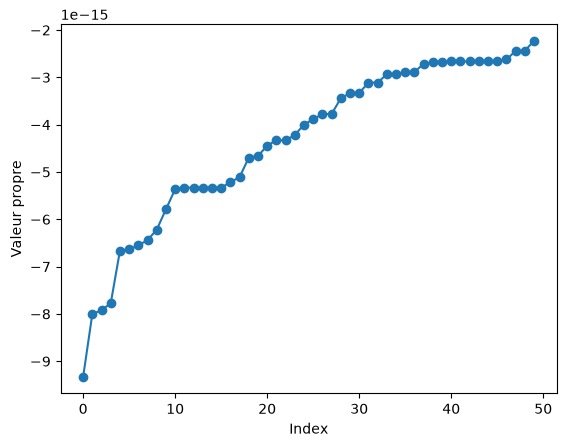

In [41]:
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh

S_full = np.block([
    [simi_source, S],
    [S.T, simi_target]
])
S_full = (S_full+S_full.T)/2
L = laplacian(S_full, normed=True)
eigenvalues = np.sort(eigh(L.toarray() if hasattr(L, 'toarray') else L, eigvals_only=True))[:50]

plt.plot(eigenvalues, 'o-')
plt.xlabel("Index")
plt.ylabel("Valeur propre")

In [ ]:
from sklearn.cluster import SpectralClustering

n_clusters = 50
model = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=0)
labels = model.fit_predict(S_full)

/opt/python/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


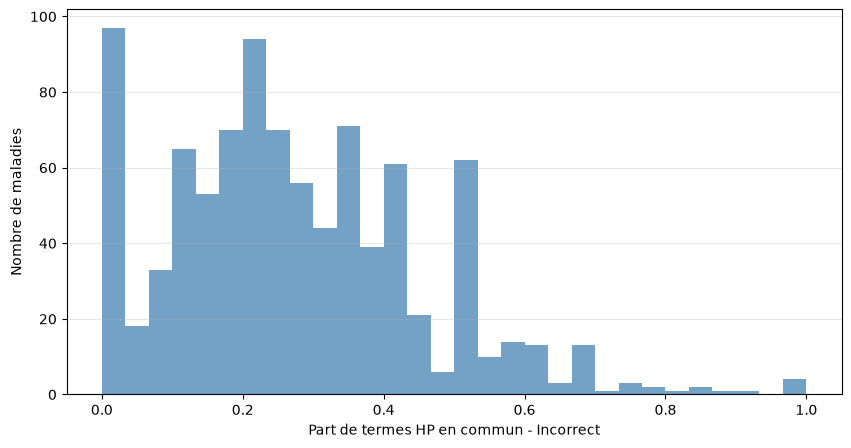

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
incorrect = [k for k, v in pairs.items() if (v[0] > 3 or v[0]==0)]

paires_zero_dict = {}
paires_correct_dict = {}
hpo_cols = [c for c in w_omim.columns if c.startswith('HP:')]
omim_to_idx = {v: i for i, v in enumerate(w_omim['database_id'].values)} 
orpha_to_idx = {v: i for i, v in enumerate(w_orpha['database_id'].values)}
idx2omim={t:v for v,t in omim_to_idx.items()}
idx2orpha={t:v for v,t in orpha_to_idx.items()}

for (i,j) in incorrect:
    omim_row = w_omim.iloc[i][hpo_cols]
    orpha_row = w_orpha.iloc[j][hpo_cols]
    omim_hpos  = omim_row[omim_row == 1].index.tolist()
    orpha_hpos = orpha_row[orpha_row == 1].index.tolist()
    disease_i = pd.unique(df_hpoa[df_hpoa['database_id']==idx2omim[i]]['disease_name'])[0]
    disease_j = pd.unique(df_hpoa[df_hpoa['database_id']==idx2orpha[j]]['disease_name'])[0]

    paires_zero_dict[(i, j)] = {
        "omim":  {"name": disease_i, "count": len(omim_hpos), "terms": omim_hpos},
        "orpha": {"name": disease_j, "count": len(orpha_hpos), "terms": orpha_hpos},
        "commun":set(omim_hpos)&set(orpha_hpos),
    }

var1 = [len(paires_zero_dict[c]["commun"])/paires_zero_dict[c]["omim"]["count"] for c in paires_zero_dict.keys()]

fig, ax = plt.subplots(figsize=(10, 5), sharex=True)

sns.histplot(var1, bins=30, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Part de termes HP en commun - Incorrect")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.show()

### Régularisation laplacienne avec une matrice de similarités à partir des PPI

In [5]:
# Inspiré du code emd_laplace de la librairie POT
from ot import sinkhorn
from ot.optim import cg, gcg
from sklearn.neighbors import kneighbors_graph

def laplacian(x):
    r"""Compute Laplacian matrix"""
    L = np.diag(np.sum(x, axis=1)) - x
    return L

def otda(
    a, b, 
    df_source, df_target, 
    C, 
    Ss, St,
    epsilon,
    eta=1., 
    alpha=0.5, 
    reg="pos", 
    numItermax=1000,
    stopThr=1e-9,
    numInnerItermax=10_000,
    stopInnerThr=1e-9,
    log=False,
    verbose=False):

    n, m = C.shape
    if a is None:
        a = np.ones(n)/n
    if b is None:
        b = np.ones(m)/m

    xs = np.asarray(df_source, dtype=np.float32)
    xt = np.asarray(df_target, dtype=np.float32)
    print('xs', xs.shape)
    print('xt', xt.shape)
    if Ss is None or St is None :
        sim_param = 10
        Ss = kneighbors_graph(X=xs, n_neighbors=int(sim_param)).toarray()
        St = kneighbors_graph(X=xt, n_neighbors=int(sim_param)).toarray()
    sS = (Ss + Ss.T) / 2  
    sT = (St + St.T) / 2
    print('sS', sS.shape)
    print('sT', sT.shape)
    print("sS symétrique ?", np.allclose(sS, sS.T))
    print("sS valeurs négatives ?", (sS < 0).any())
    print("diag(sS) :", np.diag(sS)[:5])

    lS = laplacian(sS)
    lT = laplacian(sT)
    print('lS', lS.shape)
    print('lT', lT.shape)

    ls2 = lS + lS.T
    lt2 = lT + lT.T
    xt2 = np.dot(xt, xt.T)
    xs2 = np.dot(xs, xs.T)

    if reg == "disp":
        Cs = -eta * alpha / xs.shape[0] *(ls2 @ xs @ xt.T)
        Ct = -eta * (1 - alpha) / xt.shape[0] * (xs @ xt.T @ lt2)
        C = C + Cs + Ct

    def f(G):
        #GXt = G @ xt
        #term1 = np.einsum('ij,ij->', lS @ GXt, GXt)
        term1 = np.trace(G.T.dot(ls2*0.5).dot(G))
        #GtXs = G.T @ xs
        #term2 = np.einsum('ij,ij->', lT @ GtXs, GtXs)
        term2 = np.trace(G.dot(lt2*0.5).dot(G.T))
        #return alpha * term1 + (1 - alpha) * term2
        #return 0.0
        return alpha * np.trace(xt.T @ G.T @ lS @ G @ xt) + (1 - alpha) * np.trace(xs.T @ G @ lT @ G.T @ xs)

    def df(G):
        #return np.zeros_like(G)
        #return alpha * (ls2 @ G) + (1-alpha) * (G @ lt2)
        return alpha * (ls2 @ G @ xt2) + (1 - alpha) * (xs2 @ G @ lt2)

    assert (C >= 0).all(), "C contient des valeurs négatives !"
    G_emd = sinkhorn(a, b, C, reg=0.05*np.mean(C), numItermax=10_000)
    G_emd = G_emd/G_emd.sum()
    print("G0 nan:", np.isnan(G_emd).any())
    G0Xt = G_emd @ xt
    term1 = np.einsum('ij,ij->', lS @ G0Xt, G0Xt)
    G0tXs = G_emd.T @ xs
    term2 = np.einsum('ij,ij->', lT @ G0tXs, G0tXs)
    f_Gemd = alpha * term1 + (1 - alpha) * term2

    print("f(G_emd):", f_Gemd) 
    print("⟨G_emd, C⟩ :", np.sum(G_emd * C))
    print("ratio :", np.sum(G_emd * C) / f_Gemd)
    eta_calibrated = np.sum(G_emd*C)/(f_Gemd+1e-10)
    return cg(
        a,
        b,
        C,
        reg=eta * eta_calibrated,
        #reg2=epsilon,
        f=f,
        df=df,
        G0=None,
        numItermax=20, 
        numInnerItermax=100_000, 
        stopThr=1e-09, 
        stopThr2=1e-09, 
        verbose=True
    )


In [ ]:
df1_omim_da = df1_omim[df1_omim['disease_id'].isin(w_omim_P['database_id'])].reset_index()
df1_orpha_da = df1_orpha[df1_orpha['disease_id'].isin(w_orpha_P['database_id'])].reset_index()

simi_source = simi_ppi(df1_omim_da)
simi_target = simi_ppi(df1_orpha_da)

w_omim_da = w_omim_P[w_omim_P['database_id'].isin(df1_omim_da['disease_id'])].reset_index()
w_orpha_da = w_orpha_P[w_orpha_P['database_id'].isin(df1_orpha_da['disease_id'])].reset_index()
work_cols = [c for c in w_omim_da.columns if c.startswith("HP")]
gt_set_da, valid_omim_da, valid_orpha_da = f_ground_truth(w_omim_da, w_orpha_da, df_orpha_omim_exact)

/tmp/ipykernel_3072/2478979160.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  w_omim_da = w_omim_P[w_omim_P['database_id'].isin(df1_omim_da['disease_id'])].reset_index()
/tmp/ipykernel_3072/2478979160.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  w_orpha_da = w_orpha_P[w_orpha_P['database_id'].isin(df1_orpha_da['disease_id'])].reset_index()


Text(0.5, 1.0, 'Target')

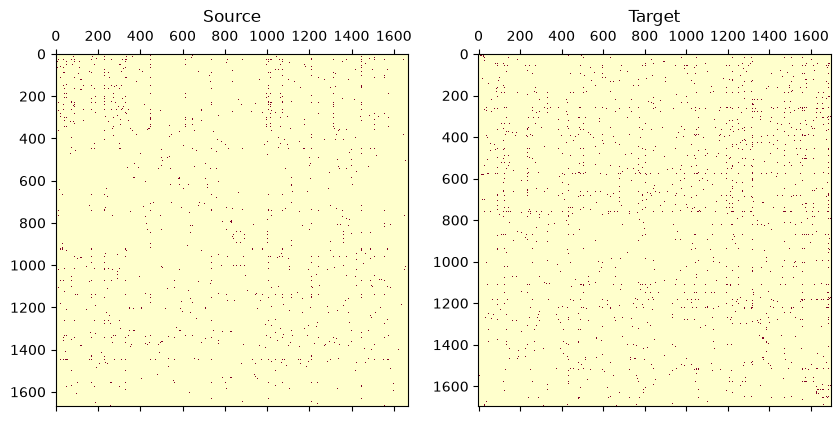

In [7]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].matshow(simi_source, cmap="YlOrRd")
axes[0].set_title("Source")
axes[1].matshow(simi_target, cmap="YlOrRd")
axes[1].set_title("Target")

In [ ]:
# Densité du graphe
print("Densité Source:", (simi_source > 0).sum() / (simi_source.shape[0]**2))
# Distribution des degrés
degrees = (simi_source > 0).sum(axis=1)
print("Degré moyen :", degrees.mean())
print("Nœuds isolés :", (degrees == 0).mean())

# Pour les paires ground truth : sont-elles proches ?
for (i, j) in list(gt_set_da)[:10]:
    if i < len(simi_source):
        print(f"Degré maladie source {i} : {degrees[i]}, "
              f"voisins communs avec autres maladies transportées vers {j}")

Densité Source: 0.008088493234189626
Degré moyen : 13.491606714628297
% nœuds isolés : 0.08633093525179857
Degré maladie source 614 : 25, voisins communs avec autres maladies transportées vers 457
Degré maladie source 440 : 78, voisins communs avec autres maladies transportées vers 649
Degré maladie source 1347 : 11, voisins communs avec autres maladies transportées vers 307
Degré maladie source 1243 : 6, voisins communs avec autres maladies transportées vers 106
Degré maladie source 1239 : 5, voisins communs avec autres maladies transportées vers 1304
Degré maladie source 527 : 13, voisins communs avec autres maladies transportées vers 838
Degré maladie source 1522 : 0, voisins communs avec autres maladies transportées vers 954
Degré maladie source 1364 : 8, voisins communs avec autres maladies transportées vers 517
Degré maladie source 949 : 8, voisins communs avec autres maladies transportées vers 9
Degré maladie source 1620 : 3, voisins communs avec autres maladies transportées ver

In [7]:
C_da = tree.tsw_matrix(w_omim_da, w_orpha_da)
for eta in [0.1, 1., 10, 100, 1000]:
    #for epsilon in [0.05, 0.1, 1, 10.]:
    #epsilon0 = epsilon * np.mean(C_da)
    print(f"Eta = {eta}")
    ot_lapl = otda(
    None, None,  # a, b
    w_omim_da[work_cols], w_orpha_da[work_cols], 
    C_da, 
    simi_source, simi_target,  # Ss, St
    0.1, 
    eta, 
    alpha=0.5)
    print("transport computed")
    ranks_lapl, pairs_lapl = evaluate_transport(ot_lapl, gt_set_da, C_da)

100%|██████████| 7/7 [02:03<00:00, 17.67s/it]


Eta = 0.1
xs (1668, 11613)
xt (1696, 11613)
sS (1668, 1668)
sT (1696, 1696)
sS symétrique ? True
sS valeurs négatives ? False
diag(sS) : [0. 0. 0. 0. 0.]
lS (1668, 1668)
lT (1696, 1696)
G0 nan: False
f(G_emd): 0.19061081487068196
⟨G_emd, C⟩ : 52.05950884081479
ratio : 273.11938662102705
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|8.056697e+01|0.000000e+00|0.000000e+00
    1|6.411217e+01|2.566564e-01|1.645480e+01
    2|5.781829e+01|1.088563e-01|6.293887e+00
    3|5.522588e+01|4.694194e-02|2.592410e+00
    4|5.407360e+01|2.130935e-02|1.152274e+00
    5|5.337223e+01|1.314120e-02|7.013751e-01
    6|5.295076e+01|7.959657e-03|4.214699e-01
    7|5.264351e+01|5.836374e-03|3.072472e-01
    8|5.242348e+01|4.197152e-03|2.200293e-01
    9|5.227221e+01|2.893847e-03|1.512678e-01
   10|5.215304e+01|2.285059e-03|1.191728e-01
   11|5.205597e+01|1.864740e-03|9.707083e-02
   12|5.198030e+01|1.455765e-03|7.567112e-02
   13|5.191870e+01|1.186424e-03

In [13]:
C_da = tree.tsw_matrix(w_omim_da, w_orpha_da)
epsilon0 = 0.1
ot_lapl = otda(
    None, None,  # a, b
    w_omim_da[work_cols], w_orpha_da[work_cols], 
    C_da, 
    simi_source, simi_target,  # Ss, St
    epsilon0, 
    0.0, 
    alpha=0.5)
print("transport computed")
ranks_lapl, pairs_lapl = evaluate_transport(ot_lapl, gt_set_da, C_da)

100%|██████████| 7/7 [02:29<00:00, 21.31s/it]


xs (1668, 11613)
xt (1696, 11613)
sS (1668, 1668)
sT (1696, 1696)
sS symétrique ? True
sS valeurs négatives ? False
diag(sS) : [0. 0. 0. 0. 0.]
lS (1668, 1668)
lT (1696, 1696)
G0 nan: False
f(G_emd): 0.19061081487068196
⟨G_emd, C⟩ : 52.05950884081479
ratio : 273.11938662102705
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|8.056697e+01|0.000000e+00|0.000000e+00
    1|4.381302e+01|8.388818e-01|3.675395e+01
    2|4.344549e+01|8.459785e-03|3.675395e-01
    3|4.344181e+01|8.460501e-05|3.675395e-03
    4|4.344177e+01|8.460508e-07|3.675395e-05
    5|4.344177e+01|8.460508e-09|3.675395e-07
    6|4.344177e+01|8.460511e-11|3.675396e-09
transport computed
Paires évaluées : 1583
Top-1 accuracy : 0.525 (831/1583)
Top-3 accuracy : 0.626 (991/1583)
Top-5 accuracy : 0.626 (991/1583)
 Rang moyen: 317.56


# PecanPy (Node2Vec)

In [ ]:
print('Union diseases')
union_diseases = add_corresponding_terms(work_omim, work_orpha, df_orpha_omim)
print('Add edges')
G_hpo_omim = add_edges(union_diseases, G_hpo_work, depths)
print("End of preprocessing")
G_hpo_omim.add_edge('HP:6001347', 'HP:0001832')

label_to_id = {node: str(i) for i, node in enumerate(G_hpo_omim.nodes())}
id_to_label = {v: k for k, v in label_to_id.items()}
G_clean = nx.relabel_nodes(G_hpo_omim, label_to_id)  # Nouveaux labels pour éviter les pollutions

objects = list(G_hpo_omim.nodes())
edges = np.array([(label_to_id[u], label_to_id[v]) for u, v in G_hpo_omim.edges()],dtype=int)
#nx.write_edgelist(G_clean, "graph.edg", delimiter="\t", data=False)
#nx.write_edgelist(G_hpo_omim, "graph.edg", delimiter="\t", data=False)

Union diseases


Fusion HPO: 100%|██████████| 5312/5312 [00:00<00:00, 6131.79it/s]


Add edges


100%|██████████| 6562/6562 [00:11<00:00, 560.81it/s]


End of preprocessing


In [3]:
nodes_to_keep = [c for c in union_diseases.columns if c.startswith('HP')]
G_sub = G_hpo_omim.subgraph(nodes_to_keep).copy()

print(f"Noeuds : {G_hpo_omim.number_of_nodes()} → {G_sub.number_of_nodes()}")
print(f"Arêtes : {G_hpo_omim.number_of_edges()} → {G_sub.number_of_edges()}")

Noeuds : 19391 → 11613
Arêtes : 2186608 → 2174438


In [3]:
import numpy as np
import pandas as pd

nodes = []
vectors = []

with open("graph.emb", "r") as f:
    next(f)
    i=0
    for line in f:
        i+=1
        parts = line.strip().split()
        try:
            vec = np.array(parts[1:], dtype=np.float32)
            nodes.append(parts[0])
            vectors.append(vec)
        except ValueError:
            print(f"Ligne {i} ignorée : {line[:]}")
df = pd.DataFrame(vectors, index=nodes)
df.index = [int(label_to_id[i]) for i in df.index]
df_sorted = df.sort_index()
max_id = df_sorted.index.max()
df_sorted = df_sorted.reindex(range(max_id + 1))
ignored_label = [c for c in id_to_label.keys() if not np.isin(int(c), df_sorted.index)]

Ligne 17214 ignorée : Comment: Affected individuals may present with foot pain on weight-bearing, swelling, and tenderness. Radiological features include widening of the metatarsophalangeal joint space and flattening of the affected metatarsal head, at later stages metatarsal head sclerosis, cortical thickening, and intra-articular loose bodies. Osteochondrosis is a condition resulting from an epiphysis injury that alters enchondral ossification and produces irregularity at the joint surface. Freiberg disease is characterized as osteochondrosis of the metatarsal heads (primarily the second)."", xrefs=('PMID:30685014', 'PMID:30725993')"")" 0.0821505 0.012895118 -0.067146435 -0.11278694 0.105025284 0.03998919 0.020470139 0.032430608 0.10429149 -0.099818945 0.06482978 -0.02671577 0.112023905 0.03470147 0.04848226 0.10817434 -0.09108107 0.02597665 -0.018610151 -0.07946276 -0.019600997 -0.004767047 -0.007365023 -0.086254686 -0.022665929 -0.06743415 0.052404623 -0.16472206 -0.019311633 -0.03

In [40]:
from collections import defaultdict
from tqdm import tqdm
from sklearn.metrics import average_precision_score

def evaluate(weights, objects, edges, node2id):

    pos_neighbors = defaultdict(set)
    for u, v in edges:
        pos_neighbors[int(u)].add(int(v))
    w = weights.values
    n = w.shape[0]
    ap_scores = []
    ranks_all = []
    labels = np.zeros(n)

    for obj in tqdm(objects):
        u = int(node2id[obj])  # Identifiant du terme 
        neighbors = pos_neighbors.get(u, set())
        if not neighbors:
            continue
        if np.any(np.isnan(w[u])):
            continue
        u_emb = np.tile(w[u], (n, 1))
        dists = np.linalg.norm(u_emb-w, axis=1)
        dists[u] = float('inf')
        dists[np.isnan(dists)] = float('inf')

        max_finite = dists[np.isfinite(dists)].max()
        dists[~np.isfinite(dists)] = max_finite + 1.0

        sorted_ind = np.argsort(dists)
        ranks = np.where(np.isin(sorted_ind, list(neighbors)))[0] + 1

        n_neighbors = len(neighbors)
        corrected_ranks = ranks - np.arange(n_neighbors)
        ranks_all.extend(corrected_ranks.tolist())

        labels.fill(0)
        labels[list(neighbors)] = 1
        ap_scores.append(average_precision_score(labels, -dists))

    map_score  = float(np.mean(ap_scores))
    mean_rank  = float(np.mean(ranks_all))
    return map_score, mean_rank
  

In [41]:
results = evaluate(df_sorted, objects, edges, label_to_id)
results

100%|██████████| 19391/19391 [08:01<00:00, 40.31it/s]


(0.028388536478705838, 4453.802849255879)

In [5]:
from joblib import Parallel, delayed
from tqdm import tqdm
from OT_utils import compute_transport
from information_content import deprecated

def compute_costs_matrix_wasserstein2(df_omim, df_orpha, node2id_w, df_weights, deprecated):
    n=len(df_omim)
    m=len(df_orpha)
    hpo_cols = [c for c in df_omim.columns if c.startswith('HP:')]
    W = df_weights.values
    print(type(W))

    print("Precompute...")
    def precompute(df):
        '''
        Renvoie pour chaque maladie (ligne) du dataframe df la liste des termes HPO actifs et 
        le vecteur de poids uniformes associés.
        '''
        X = df[hpo_cols].to_numpy(dtype=bool)
        resolved_cols = np.array(
            [deprecated.get(col, col) if deprecated.get(col, col) in node2id_w else None for col in hpo_cols], 
            dtype=object)
        valid_mask = resolved_cols != None
        X_valid = X[:, valid_mask]
        resolved_valid = resolved_cols[valid_mask]
        terms = [list(resolved_valid[row_mask]) for row_mask in X_valid]
        weights = [np.ones(len(t)) / len(t) if t else np.array([]) for t in terms]
        return terms, weights

    terms_i, weights_i = precompute(df_omim)  # Termes actifs, poids pour les maladies sources
    terms_j, weights_j = precompute(df_orpha)  # Termes actifs, poids pour les maladies destinations
    print("Finished !")

    all_terms = list({h for ts in terms_i + terms_j for h in ts})  # Tous les termes actifs
    term2idx = {h: k for k, h in enumerate(all_terms)}
    missing = [h for h in all_terms if h not in node2id_w]
    print(f"Termes absents de node2id_w : {missing[:10]}")
    E = W[[int(node2id_w[h]) for h in all_terms]]  # Embeddings des termes actifs
    E = E.astype(np.float32)

    idx_i = [[term2idx[h] for h in ts] for ts in terms_i]  # Index des termes actifs par maladies sources
    idx_j = [[term2idx[h] for h in ts] for ts in terms_j]  # Index des termes actifs par maladies destinations

    C = np.zeros((n,m))

    print("Precomputing full HPO distance matrix...")
    #D_full = np.sum((E[:, None, :] - E[None, :, :]) ** 2, axis=-1)  # (K, K)
    norms = np.sum(E**2, axis=1)  # (K,)
    D_full = norms[:, None] + norms[None, :] - 2 * (E @ E.T)  # (K, K)
    D_full = np.maximum(D_full, 0)
    print(f"HPO distance matrix: {D_full.shape}")

    def compute_row(i):
        if not idx_i[i]:
            return i, np.zeros(len(terms_j))
        # Ei = E[idx_i[i]]
        row = np.zeros(len(terms_j))
        valid_js = [j for j in range(len(terms_j)) if idx_j[j]]
        for j in valid_js:
            # Ej = E[idx_j[j]]
            # M = cost_hpos(Ei, Ej) 
            M = D_full[np.ix_(idx_i[i], idx_j[j])]
            _, row[j] = compute_transport(M, weights_i[i], weights_j[j])
        return i, row
    
    results = Parallel(n_jobs=-1)(
        delayed(compute_row)(i) for i in tqdm(range(len(df_omim)), desc="OMIM")
    )
    C = np.zeros((len(df_omim), len(df_orpha)))
    for i, row in results:
        C[i] = row
    return C

C = compute_costs_matrix_wasserstein2(work_omim, work_orpha, label_to_id, df, deprecated)

<class 'numpy.ndarray'>
Precompute...
Finished !
Termes absents de node2id_w : []
Precomputing full HPO distance matrix...
HPO distance matrix: (10649, 10649)


OMIM: 100%|██████████| 6562/6562 [24:40<00:00,  4.43it/s]


In [9]:
from OT_utils import compute_transport, compute_transport_sinkhorn, evaluate_transport
print("======== Sans régularisation ========")
ot_plan, ot_cost = compute_transport(C, None, None)
ranks, pairs = evaluate_transport(ot_plan, gt_set, C)

print("======== Avec régularisation ========")
epsilon = 0.1*np.mean(C)
ot_plan_reg, ot_cots_reg = compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, pairs_reg = evaluate_transport(ot_plan_reg, gt_set, C)

======== Sans régularisation ========
Paires évaluées : 5312
Top-1 accuracy : 0.000 (1/5312)
Top-3 accuracy : 0.001 (5/5312)
Top-5 accuracy : 0.001 (6/5312)
 Rang moyen: 1644.73
======== Avec régularisation ========
Paires évaluées : 5312
Top-1 accuracy : 0.000 (1/5312)
Top-3 accuracy : 0.001 (4/5312)
Top-5 accuracy : 0.001 (6/5312)
 Rang moyen: 1584.41
